In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({
    'figure.dpi': 180,
    'savefig.dpi': 320,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})


def bt(f, g, x, p):
    a, fx, m = 1.0, f(x), g(x) @ p
    if m >= 0:
        return 0.0
    while a > 1e-12:
        xn = x + a * p
        if np.isfinite(f(xn)) and f(xn) <= fx + 1e-4 * a * m:
            return a
        a *= 0.5
    return 0.0


def make_pd(H):
    ev = np.linalg.eigvalsh(H)
    s = max(0.0, 1e-8 - ev.min())
    return H + s * np.eye(len(H)), ev, s


def gd(f, g, x0, n=3000, tol=1e-10):
    x = np.array(x0, float)
    xs = [x.copy()]
    for _ in range(n):
        if np.linalg.norm(g(x)) < tol:
            break
        a = bt(f, g, x, -g(x))
        if a == 0:
            break
        x = x - a * g(x)
        xs.append(x.copy())
    return np.array(xs)


def newton(f, g, H, x0, n=80, tol=1e-10):
    x = np.array(x0, float)
    xs, evs, shifts = [x.copy()], [], []
    for _ in range(n):
        gx = g(x)
        if np.linalg.norm(gx) < tol:
            break
        Hp, ev, s = make_pd(H(x))
        p = -np.linalg.solve(Hp, gx)
        a = bt(f, g, x, p)
        if a == 0:
            break
        evs.append(ev)
        shifts.append(s)
        x = x + a * p
        xs.append(x.copy())
    return np.array(xs), np.array(evs), np.array(shifts)


z = np.array([1.0, -1.0])


def embed(t):
    return np.array([t, -t - 1.0])


def newton_line(f, g, H, t0, n=80, tol=1e-12):
    t = float(t0)
    xs = [embed(t)]
    for _ in range(n):
        x = embed(t)
        d1 = g(x) @ z
        if abs(d1) < tol:
            break
        d2 = z @ H(x) @ z
        p = -d1 / d2
        a = 1.0
        while f(embed(t + a * p)) > f(x) + 1e-4 * a * d1 * p and a > 1e-12:
            a *= 0.5
        t = t + a * p
        xs.append(embed(t))
    return np.array(xs)


def phi(x):
    return 1.0 - ((x[0] - 1.0) ** 2 + x[1] ** 2)


def interior(f, g, H, x0, mu=1.0, factor=0.2, outer=6):
    x = np.array(x0, float)
    xs, evs, shifts = [x.copy()], [], []
    for _ in range(outer):
        def fb(v):
            q = phi(v)
            return np.inf if q <= 0 else f(v) - mu * np.log(q)

        def gb(v):
            q = phi(v)
            w = np.array([2 * (v[0] - 1.0), 2 * v[1]])
            return g(v) + mu * w / q

        def Hb(v):
            q = phi(v)
            w = np.array([2 * (v[0] - 1.0), 2 * v[1]])
            return H(v) + mu * ((2 / q) * np.eye(2) + np.outer(w, w) / q ** 2)

        part, part_evs, part_shifts = newton(fb, gb, Hb, x, n=40)
        if len(part) > 1:
            xs.extend(part[1:])
        if len(part_evs):
            evs.extend(part_evs)
            shifts.extend(part_shifts)
        x = part[-1]
        mu *= factor
    return np.array(xs), np.array(evs), np.array(shifts)


def grid(f, xr, yr, n=220):
    x = np.linspace(*xr, n)
    y = np.linspace(*yr, n)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[f(np.array([a, b])) for a in x] for b in y])
    return X, Y, Z


def draw(ax, traj, label, c):
    ax.plot(traj[:, 0], traj[:, 1], "-o", ms=3, lw=1.5, color=c, label=f"{label} ({len(traj)-1})")
    ax.plot(traj[-1, 0], traj[-1, 1], "*", ms=12, color=c)


def show_problem(name, f, g, H, xr, yr, x0_gd, x0_n, t0, x0_i, xfree, xline, xdisk, levels):
    free_gd = gd(f, g, x0_gd)
    free_n, _, _ = newton(f, g, H, x0_n)
    line_n = newton_line(f, g, H, t0)
    disk_n, evs, shifts = interior(f, g, H, x0_i)

    steps = {
        "GD libre": len(free_gd) - 1,
        "Newton libre": len(free_n) - 1,
        "Newton recta": len(line_n) - 1,
        "Barrera disco": len(disk_n) - 1,
    }

    print(name)
    print("libre GD     ", free_gd[-1], "error =", np.linalg.norm(free_gd[-1] - xfree), "iteraciones =", steps["GD libre"])
    print("libre Newton ", free_n[-1], "error =", np.linalg.norm(free_n[-1] - xfree), "iteraciones =", steps["Newton libre"])
    print("recta Newton ", line_n[-1], "error =", np.linalg.norm(line_n[-1] - xline), "iteraciones =", steps["Newton recta"])
    print("disco barrera", disk_n[-1], "error =", np.linalg.norm(disk_n[-1] - xdisk), "iteraciones =", steps["Barrera disco"])
    if len(shifts):
        print("correcciones Hessiano =", int(np.sum(shifts > 0)), "max shift =", float(np.max(shifts)))
    print()

    X, Y, Z = grid(f, xr, yr)
    fig1, ax1 = plt.subplots(2, 2, figsize=(10, 9), constrained_layout=True)
    ax1 = ax1.ravel()

    ax1[0].contour(X, Y, Z, levels=levels)
    draw(ax1[0], free_gd, "GD", "tab:blue")
    draw(ax1[0], free_n, "Newton", "tab:orange")
    ax1[0].plot(xfree[0], xfree[1], "k*", ms=12)
    ax1[0].set_title(name + " libre")

    ax1[1].contour(X, Y, Z, levels=levels)
    xx = np.linspace(xr[0], xr[1], 200)
    ax1[1].plot(xx, -xx - 1.0, "k--")
    draw(ax1[1], line_n, "Newton", "tab:red")
    ax1[1].plot(xline[0], xline[1], "k*", ms=12)
    ax1[1].set_title("Restriccion en recta")

    ax1[2].contour(X, Y, Z, levels=levels)
    th = np.linspace(0, 2 * np.pi, 400)
    ax1[2].plot(1 + np.cos(th), np.sin(th), "k--")
    draw(ax1[2], disk_n, "barrera", "tab:green")
    ax1[2].plot(xdisk[0], xdisk[1], "k*", ms=12)
    ax1[2].set_title("Restriccion en disco")

    labels = list(steps)
    values = [steps[k] for k in labels]
    colors = ["tab:blue", "tab:orange", "tab:red", "tab:green"]
    ax1[3].bar(labels, values, color=colors)
    top = max(values) if values else 1
    for i, v in enumerate(values):
        ax1[3].text(i, v + 0.02 * top, str(v), ha="center", va="bottom")
    ax1[3].set_ylim(0, top * 1.12)
    ax1[3].set_title("Iteraciones hasta converger")
    ax1[3].set_ylabel("iteraciones")
    ax1[3].tick_params(axis="x", rotation=18)
    ax1[3].grid(axis="y", alpha=0.25)

    for a in ax1[:3]:
        a.set_aspect("equal")
        a.set_xlabel("x")
        a.set_ylabel("y")
        a.grid(False)
        a.legend(loc="best")
    plt.show()

    fig2, ax2 = plt.subplots(1, 1, figsize=(8, 4.5), constrained_layout=True)
    if len(evs):
        ax2.plot(evs[:, 0], "-o", ms=3, lw=1.5, label="lambda_min")
        ax2.plot(evs[:, 1], "-o", ms=3, lw=1.5, label="lambda_max")
        ax2.legend(loc="best")
    ax2.set_title(name + ": autovalores del Hessiano modificado")
    ax2.set_xlabel("iteracion")
    ax2.set_ylabel("valor")
    ax2.grid(alpha=0.3)
    plt.show()


Cuadratica: Hessiano libre PD porque sus autovalores son [ 99.583413 186.416587]
Cuadratica en recta: z^T H z = 354.0

Cuadratica
libre GD      [-0.  0.] error = 2.6988324267725293e-13 iteraciones = 38
libre Newton  [0. 0.] error = 0.0 iteraciones = 1
recta Newton  [-0.576271 -0.423729] error = 0.0 iteraciones = 1
disco barrera [0.001711 0.000342] error = 0.001744891832407594 iteraciones = 32
correcciones Hessiano = 0 max shift = 0.0



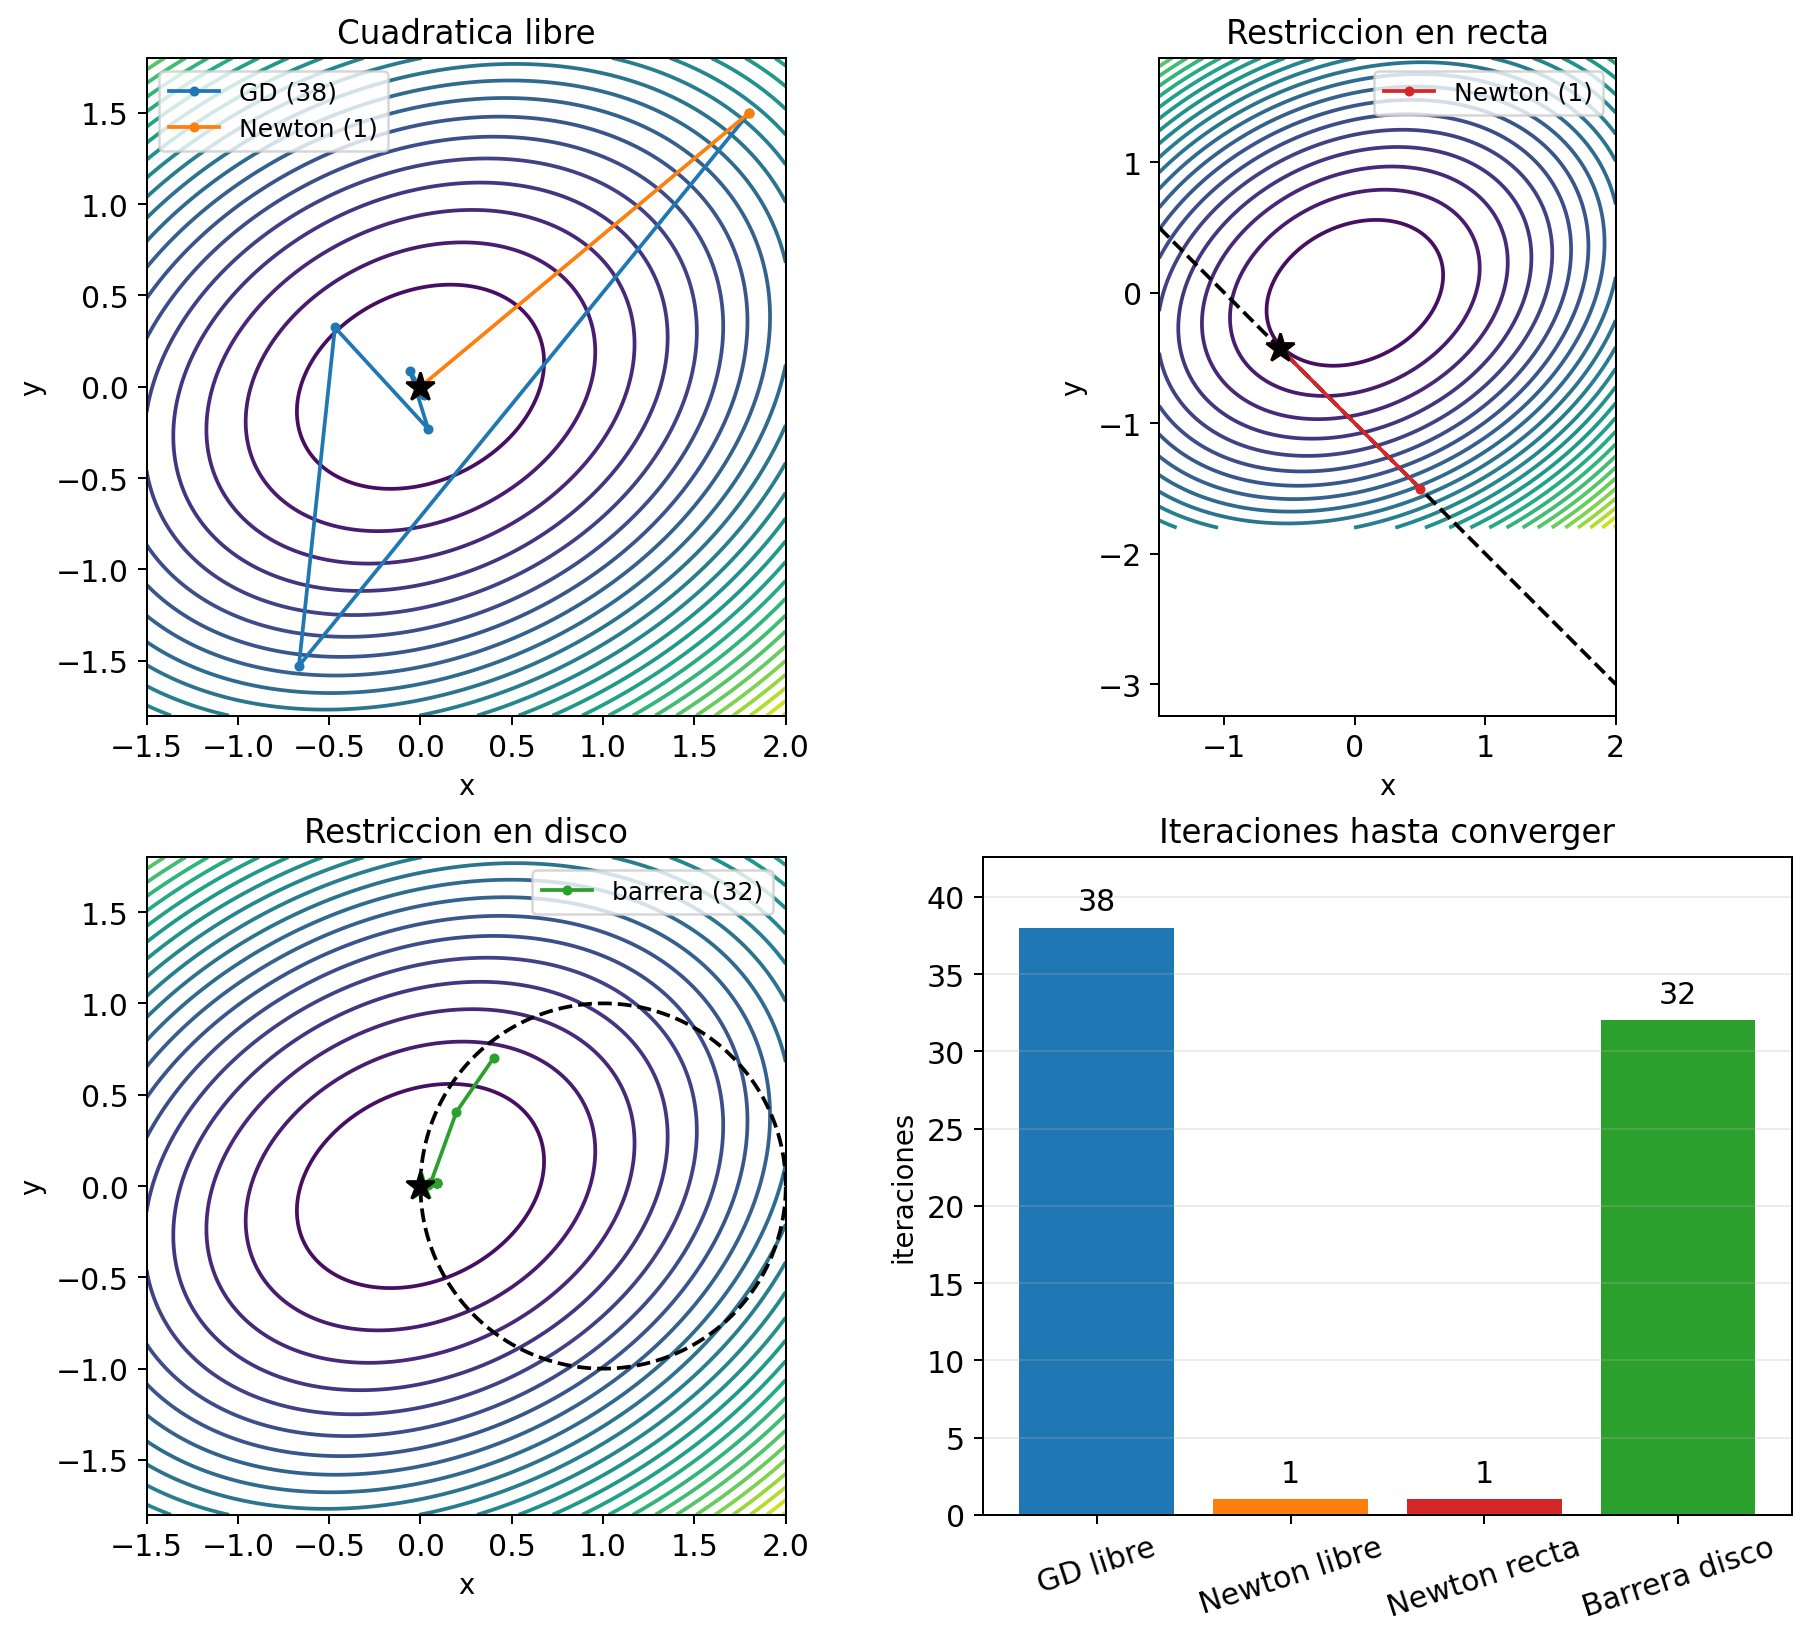

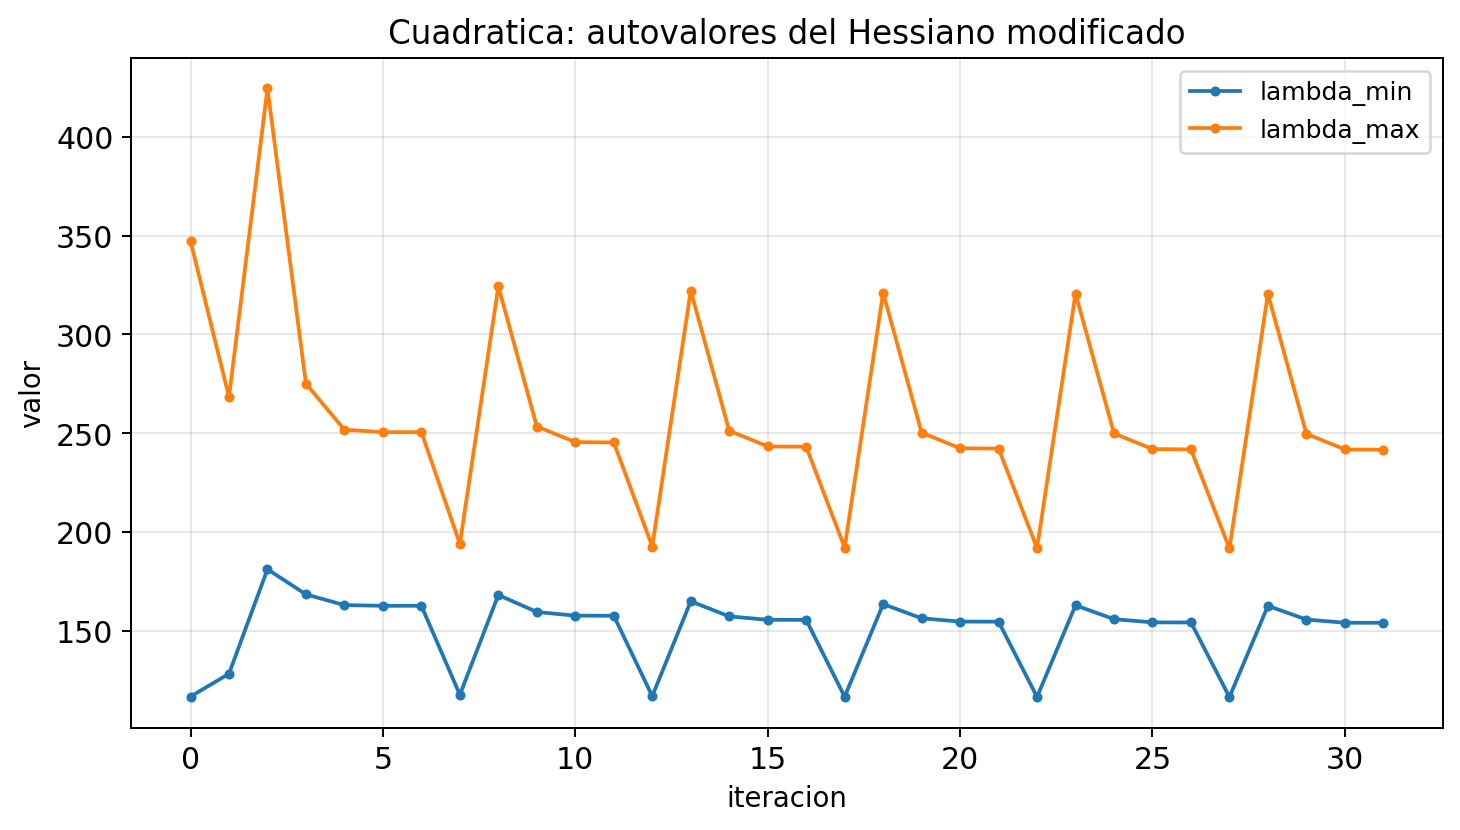

In [2]:
def fq(x):
    return 58 * x[0] ** 2 + 85 * x[1] ** 2 - 34 * x[0] * x[1]


def gq(x):
    return np.array([116 * x[0] - 34 * x[1], 170 * x[1] - 34 * x[0]])


def Hq(x):
    return np.array([[116.0, -34.0], [-34.0, 170.0]])


xq = np.array([0.0, 0.0])
xq_line = np.array([-34 / 59, -25 / 59])

print("Cuadratica: Hessiano libre PD porque sus autovalores son", np.linalg.eigvalsh(Hq(xq)))
print("Cuadratica en recta: z^T H z =", z @ Hq(xq) @ z)
print()

show_problem(
    "Cuadratica",
    fq, gq, Hq,
    (-1.5, 2.0), (-1.8, 1.8),
    [1.8, 1.5], [1.8, 1.5], 0.5, [0.4, 0.7],
    xq, xq_line, xq,
    25,
)


Rosenbrock en recta: d2/dt2 = 1200 t^2 + 1200 t + 602
discriminante = -1449600 < 0, entonces es positiva para todo t

Rosenbrock
libre GD      [1.001621 1.003245] error = 0.0036273634492732104 iteraciones = 3000
libre Newton  [1. 1.] error = 0.0 iteraciones = 20
recta Newton  [-0.490068 -0.509932] error = 1.0605390551611693e-15 iteraciones = 5
disco barrera [0.987507 0.975107] error = 0.027851999061028535 iteraciones = 64
correcciones Hessiano = 2 max shift = 135.1019725339529



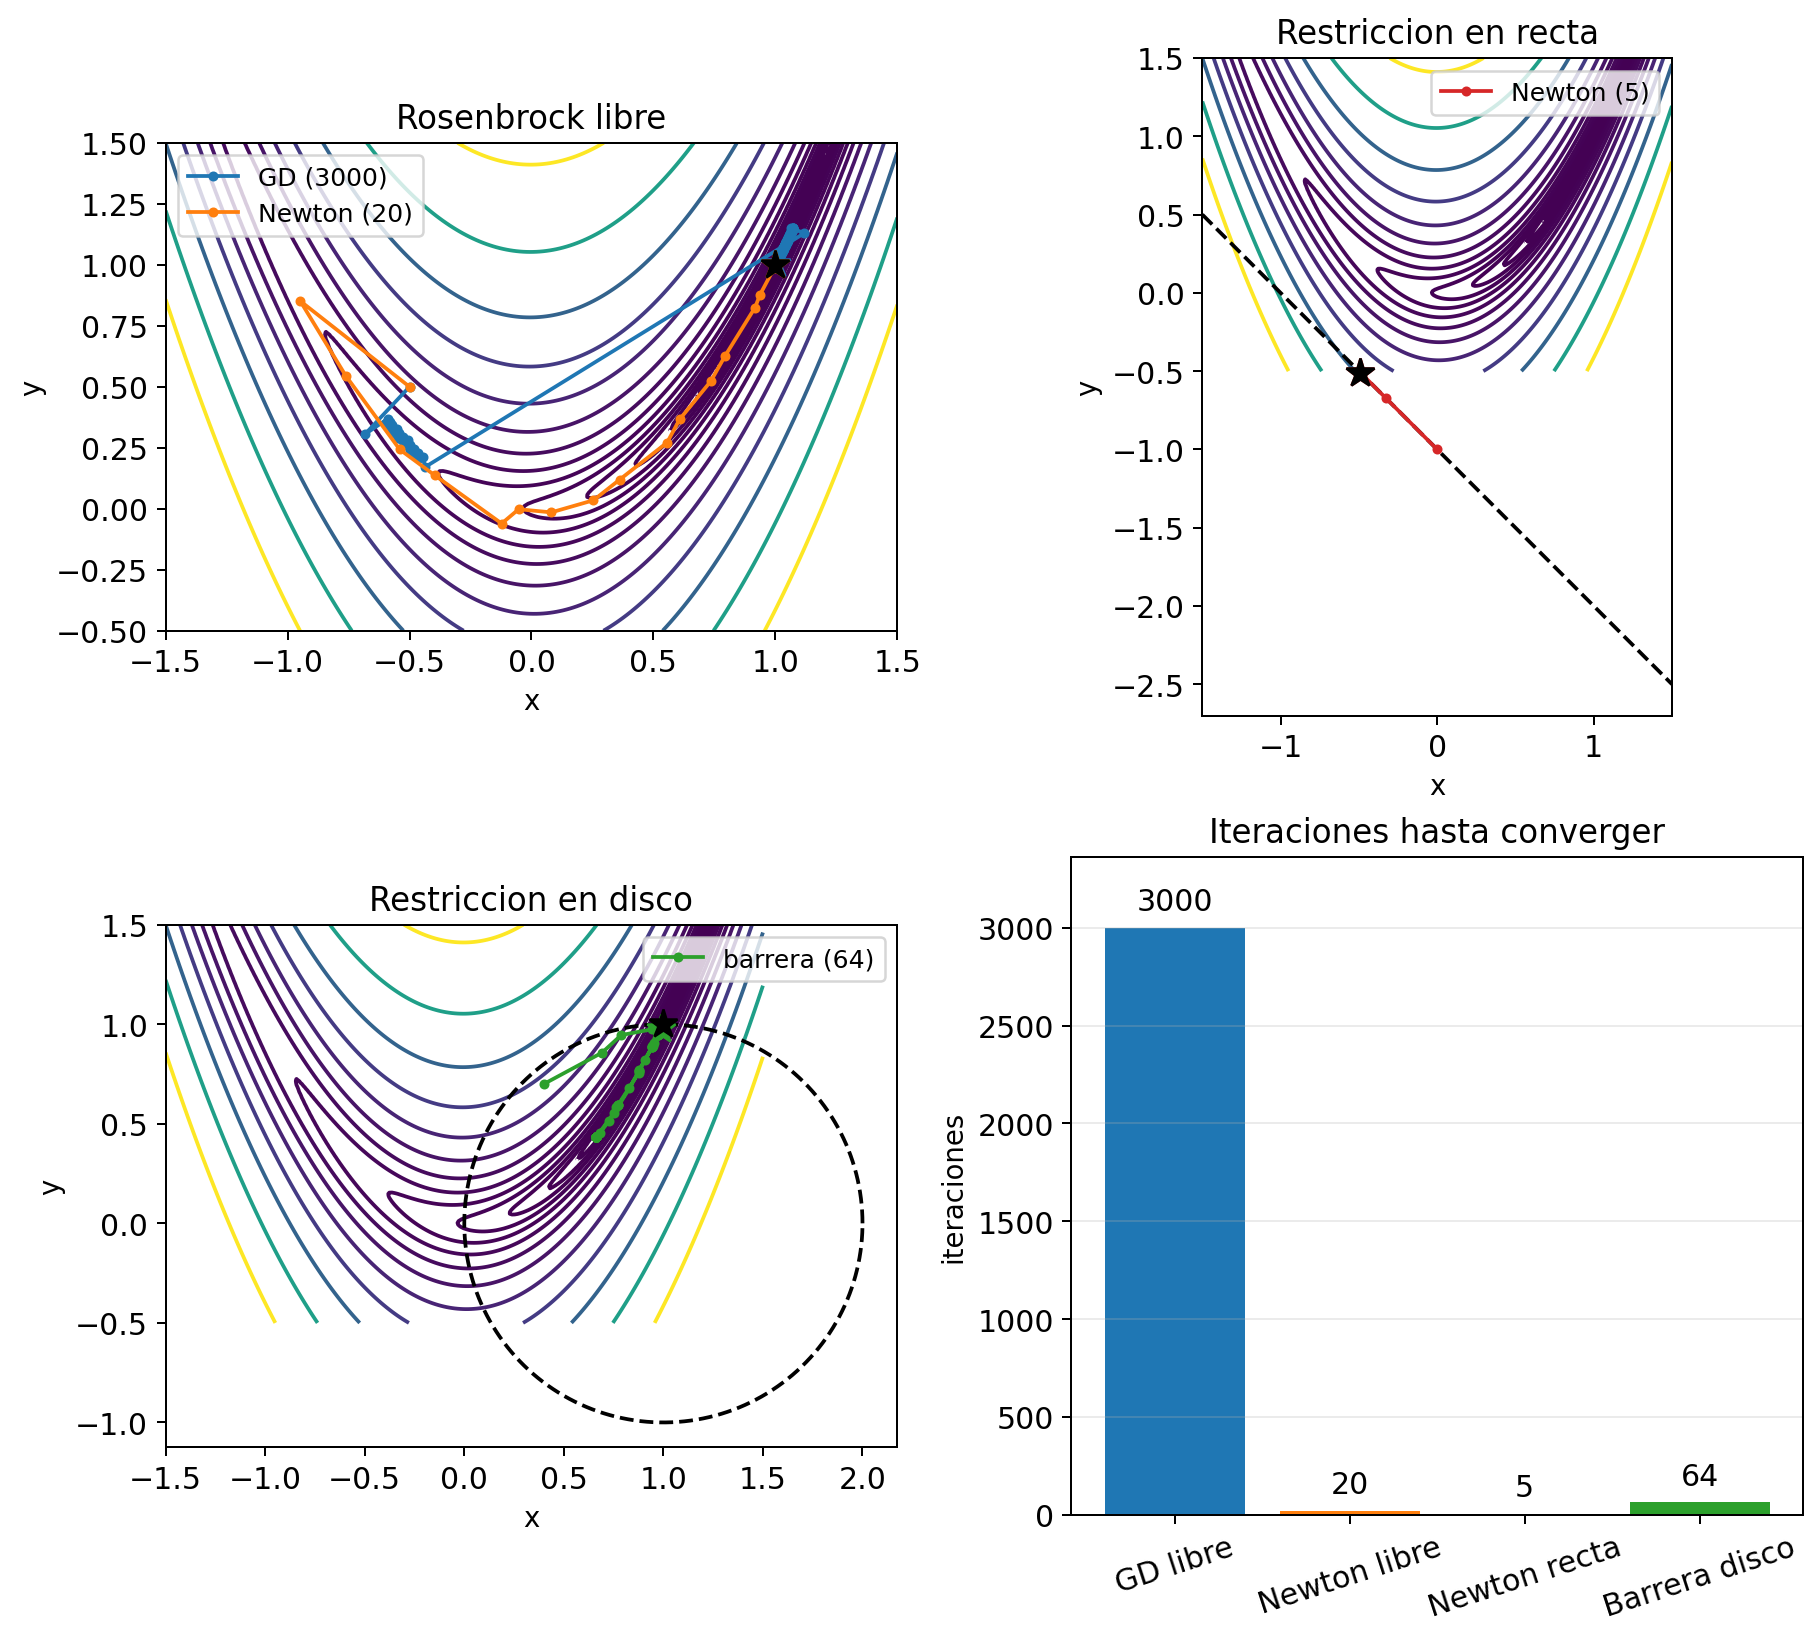

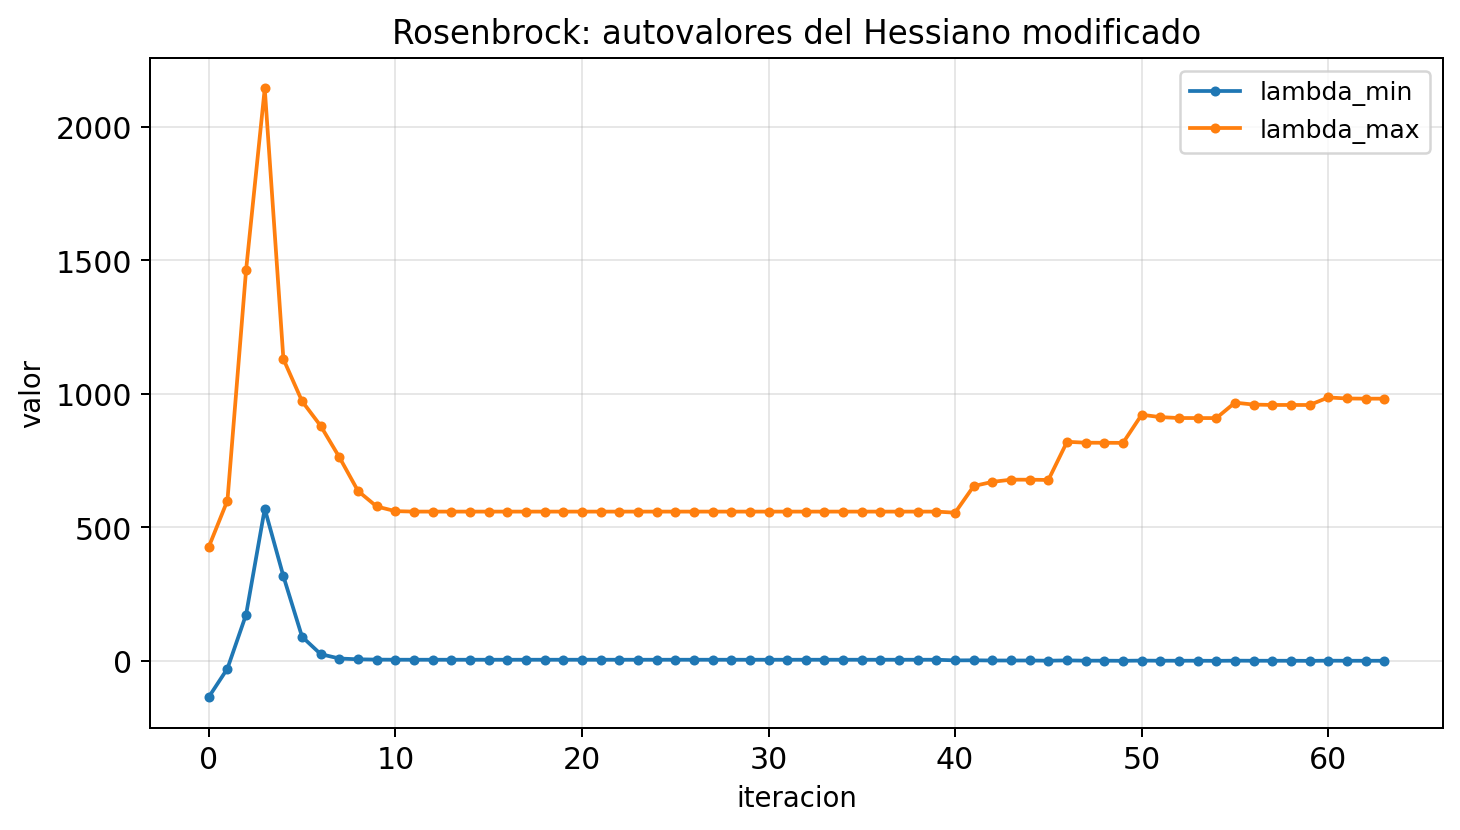

In [3]:
def fr(x):
    return (1 - x[0]) ** 2 + 100 * (x[1] - x[0] ** 2) ** 2


def gr(x):
    a, b = x
    return np.array([2 * (a - 1) - 400 * a * (b - a ** 2), 200 * (b - a ** 2)])


def Hr(x):
    a, b = x
    return np.array([[1200 * a ** 2 - 400 * b + 2, -400 * a], [-400 * a, 200.0]])


r = np.roots([200.0, 300.0, 301.0, 99.0])
tr = np.real(r[np.isclose(r.imag, 0)])[0]
xr = np.array([1.0, 1.0])
xr_line = embed(tr)

print("Rosenbrock en recta: d2/dt2 = 1200 t^2 + 1200 t + 602")
print("discriminante =", 1200 ** 2 - 4 * 1200 * 602, "< 0, entonces es positiva para todo t")
print()

show_problem(
    "Rosenbrock",
    fr, gr, Hr,
    (-1.5, 1.5), (-0.5, 1.5),
    [-0.5, 0.5], [-0.5, 0.5], 0.0, [0.4, 0.7],
    xr, xr_line, xr,
    np.geomspace(1e-3, 2e2, 22),
)
